In [1]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import sphWarpCore as sph
from sphWarpCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np
import math
import shlex    
import subprocess
import shutil

# custom SPH libraries
from integrators.integration import *
from sphWarpCore import *
from warpPlot import *

# This library
from warpSPH import *

# The case utilities that contain all the case setup functions for the various test cases
from warpSPH.caseUtils import *

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:

R = 1
L = 2 *3 * R
nx = 192
dx = L / nx
targetDt = 0.0005
rho0 = 1
freeSurface = True
band = 0
fps = 50
timeLimit = 1

dim = 2
n_h = 4


extraData = {
    'nx': nx,
    'dim': dim,
    'L': L,
    'n_h': n_h,

    'rho0': rho0,

    'R': R,
    
}

In [ ]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()



dx = L / (nx)
band = 0

domain = buildDomainDescription(L + dx * (band) * 2, dim, True, device, dtype)
interiorDomain = buildDomainDescription(L, dim, False, device, dtype)

config, integrator = buildConfig(
    domain = domain,
    dim = dim,
    kernel = KernelFunctions.Wendland4,
    targetNeighbors = n_h_to_nH(4, dim),
    supportMode = SupportScheme.KernelMeanSymmetric,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.symplecticEuler,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = None,
    adaptiveDt = True,
    cflFactor=0.3,
)
config.nx = nx + band * 2
config.dx = (interiorDomain.max[0] - interiorDomain.min[0]) / (nx)

config.minDt = 1e-8
# config.dx = L / (nx * 2)

scheme = WeaklyCompressibleSPHScheme.deltaSPH
SimulationSystem, SimulationState, SimulationConfig, SimulationUpdate, fn, export_fn, import_fn = buildScheme(scheme)


schemeConfig = SimulationConfig()
schemeConfig.surfaceDetectionConfig.active = freeSurface

In [4]:
schemeConfig.gravityConfig.active = False

In [5]:
H = 1

fluid_a = lambda points: sampleSDF(points, operatorDict['translate'](lambda x: getSDF('box')['function'](x, torch.tensor([H,H]).to(points.device)), torch.tensor([0,0]).to(points.device)), invert = False)

regions = []

regions.append(buildRegion(config, schemeConfig, fluid_a, RegionType.Fluid, initialConditions = {}))

for region in regions:
    region = filterRegion(region, regions)


for region in regions:
    region = filterRegion(region, regions)


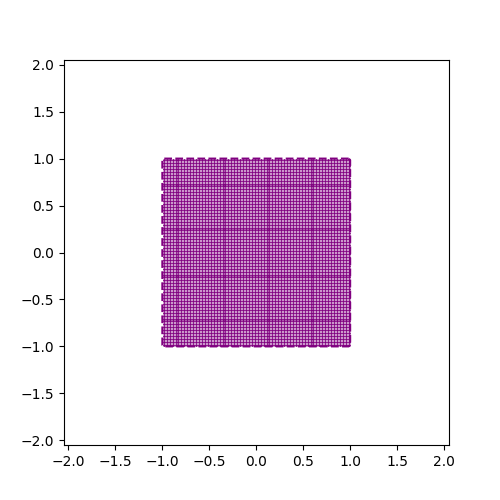

In [ ]:
fig, axis = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)
    
plotRegions(regions, axis[0,0], plotFluid = True, plotParticles = True)

rectangle = plt.Rectangle((domain.min[0].cpu().numpy(), domain.min[1].cpu().numpy()), domain.max[0].cpu().numpy() - domain.min[0].cpu().numpy(), domain.max[1].cpu().numpy() - domain.min[1].cpu().numpy(), fill=False, color='black', lw=2)
axis[0,0].add_patch(rectangle)

rectangleInterior = plt.Rectangle((interiorDomain.min[0].cpu().numpy(), interiorDomain.min[1].cpu().numpy()), interiorDomain.max[0].cpu().numpy() - interiorDomain.min[0].cpu().numpy(), interiorDomain.max[1].cpu().numpy() - interiorDomain.min[1].cpu().numpy(), fill=False, color='red', lw=2)
axis[0,0].add_patch(rectangleInterior)

import matplotlib.patches as patches

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())

for ax in axis.flatten():
    ax.set_xlim(-2.05*R, 2.05*R)
    ax.set_ylim(-2.05*R, 2.05*R)

In [ ]:
compressibleSystem = initializeWeaklyCompressibleSimulation(regions, config, schemeConfig, SimulationSystem, SimulationState, verbose = True)

omega = 4

compressibleSystem.state.velocities[:,0] = omega * compressibleSystem.state.positions[:,1]
compressibleSystem.state.velocities[:,1] = -omega * compressibleSystem.state.positions[:,0]

schemeConfig.fluid.fixedSoundSpeed, config.dt = setupWeaklyCompressibleTimestep(config, schemeConfig, compressibleSystem, targetDt, verbose = True)

Computed c0: 34.54248809814453, target c0: 10.0, diff: 24.54248809814453
Computed dt: 0.00011000000085914508, target dt: 0.0005, diff: 0.0003900000301655382
Max velocity: 5.568465709686279, CFL: 0.019600998610258102, Max Mach: 0.16120627522468567


In [8]:
runningState = compressibleSystem.initializeNewState()

caseName = 'squarePatch'
exportPath = prepExport(f'{caseName}', config, schemeConfig, scheme, export_fn)
exportSimulationSystem(exportPath, 'initialState', scheme, compressibleSystem, exportAdjacency = False, stages = None, exportStagesAdjacency = False, extraData = dict({
    'frame_num': 0,
}, **extraData))

In [10]:

markerSize = 8
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B": runningState.state.densities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            boundaryVisualization = VisualizeOptions.Visualize,
            mapping = Mapping.L2Norm,
            plotTitle = "velocities",
            # gridVisualization = GridVisualization(
            #     resolution = 1024,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "densities",
            boundaryVisualization = VisualizeOptions.Hide,
            vMin = 0.99,
            vMax = 1.01
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

imagePath = f'{exportPath}/images'
os.makedirs(imagePath, exist_ok = True)
plotter.export(f'{imagePath}/frame_00000.png', dpi  = 300)


RFBOutputContext()

In [ ]:
nSteps = int(timeLimit / config.dt)

runningState = compressibleSystem.initializeNewState()
# nSteps = 1500
kes = []
priorStep = None
for i in (tq := tqdm(range(nSteps), leave = False)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,  
        config = config,
        schemeConfig = schemeConfig,
        verbose = False,
        # priorStep = priorStep
    )
    kes.append(torch.sum(0.5 * result.state.state.masses * torch.sum(result.state.state.velocities**2, dim=1)))
    # print('max_vel:', torch.linalg.norm(result.state.state.velocities, dim = -1).max())
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state

    if (i % 10 == 0 and i > 0) or (i == nSteps - 1):
        plotter.updateQuantities(
            {
                "A": runningState.state.velocities,
                "B": runningState.state.densities,
            },
            newParticleState = runningState.state,
        )
        plotter.export(f'{imagePath}/frame_{i:05d}.png', dpi = 300)
        
    maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{timeLimit:8.4g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break
    if torch.any(torch.isnan(runningState.state.velocities)):
        print("NaN detected in velocities, stopping simulation.")
        break



  0%|          | 0/3995 [00:00<?, ?it/s]

In [ ]:
exportSimulationSystem(exportPath, f'finalState', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**extraData, **{
    'frame_num': i,
}))

In [15]:
ffmpeg_cmd = "ffmpeg -y -loglevel error -hide_banner -framerate 120 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4"
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)

# now copy the output.mp4 and out.gif to the parent directory for easier access
shutil.copy(f'{imagePath}/output.mp4', f'{exportPath}/output.mp4')
# shutil.copy(f'{imagePath}/out.gif', f'{exportPath}/out.gif');

'export/squarePatch/output.mp4'